# Classificació MNIST multiclasse

El conjunt de dades MNIST (Modified National Institute of Standards and Technology) Digits és un dels datasets més populars en el món de l'aprenentatge automàtic. És una col·lecció de 70.000 imatges, de 28x28 en escala de grisos, de dígits escrits a mà i s'utilitza comunament per a entrenar models de reconeixement d'imatges i com un punt de referència per a nous algorismes. En el nostre cas l'usarem per a comprovar com entrenar models que estem veient i avaluar-los.

Però, les imatges són de dues dimensions i estem treballant amb dades tabulades en columnes (cada columna corresponent a cada variable independent seria una dimensió). Com convertim l'una en l'altra? És molt fàcil, i de passada ens demostra la potència d'aquests algorismes que són agnòstics respecte a informació o coneixement, només veuen números.

In [2]:

import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=True)


## Preparació de les dades

In [3]:
# El dataset és de tipus Bunch, que és un diccionari amb atributs accessibles com a propietats.
print(type(mnist))
# El resultat de fetch_openml és un diccionari amb les següents claus:
print(mnist.keys())
# Data conté les imatges en format vectorial (cada imatge és un vector de 784 dimensions)
print(mnist.data.shape)
# Target conté les etiquetes (els dígits)
print(mnist.target.shape)
# Frame conté les dades en format de DataFrame de pandas, conté les imatges i les etiquetes
print(mnist.frame.shape)
mnist.frame.head()

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(70000, 784)
(70000,)
(70000, 785)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [4]:
# Ens asegurem que les etiquetes són de tipus enter i no hi ha valors nuls o extrems
mnist.target = mnist.target.astype(np.int8)
np.unique(mnist.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int8)

In [5]:
X, y = mnist["data"], mnist["target"]
type(X), type(y)

(pandas.DataFrame, pandas.Series)

Ja tenim el dataset. Com que són imatges, les podem representar per veure cóm són. Això no és un pas imprescindible a l'entrenament del model, però fer una mínima exploració de les dades és important en la documentació del procés. També verifiquem que les dades són correctes. 

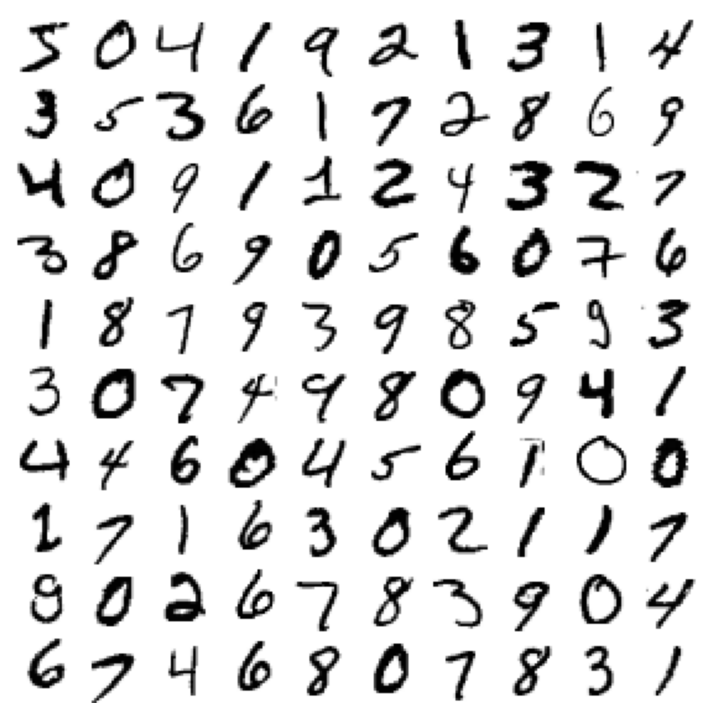

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)

    n_rows = (len(instances) - 1) // images_per_row + 1
    # otra forma de indicar el número de filas seria:
    # n_rows = ceil(len(instances) / images_per_row)   *ceil* proporciona el número entero del cociente
    
    # Añadimos imagenes vacias para completar la cuadrícula
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # En el caso de encontra imágenes de diferente tamaño al establecido, esto orden las reajusta a ese tamaño
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Se combinan los ejes 0 y 2 (verticales) con 1 y 3 (horizontales)
    # primero se colocan uno al lado del otro y se trasponen
    # reajustamos el tamaño de la imagen y obtenemos la caracterisitca de esa observaciñon
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    
    # Tras realizar la transformación como deseamos de la imagen ya podemos mostrarla
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

plt.figure(figsize=(9,9))
example_images = X[:100] 


plot_digits(example_images, images_per_row=10) 
plt.show()


## Entrenament amb un classificador binari

En el primer exemple veurem cóm detectar el número 5 front a tots els demés. És a dir, serà positiu si és un 5 i negatiu si és un altre número.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fem una operació booleana amb el conjunt d'etiquetes per crear un conjunt de dades binari on només ens interessen els dígits 5.
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)    # True for all 5s, False for all other digits

Ens interessa explorar un classificador amb hiperparàmetres que siga ràpid i amb descens de gradient. 

Els hiperparàmetres són:
* max_iter: El total màxim d'iteracions.
* tol: Criteri de parada, si arriba a aquest error es considera suficientment bó i para. 

> Tot i que internament està dissenyat a partir de classificadors lineals binaris, pot gestionar múltiples classes de manera automàtica. Estratègia One-vs-All (OvA): Per a un problema amb $K$ classes, l'algorisme entrena $K$ classificadors binaris diferents. Cadascun d'ells aprèn a distingir una de les classes de la resta de classes conjuntament. Predicció: Quan li passes una mostra, calcula la puntuació de confiança de cada classificador binari i tria la classe que obté la puntuació més alta.

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

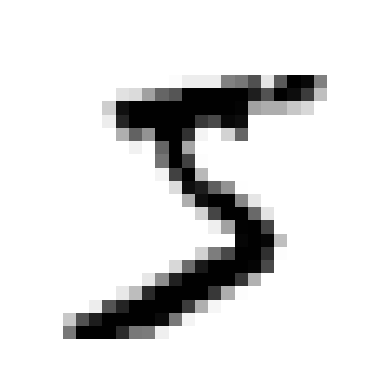

[False] 5


In [9]:


some_digit_image = X.iloc[0].to_numpy().reshape(28, 28) 
plt.imshow(some_digit_image, cmap=mpl.cm.binary) #indicamos que sea el color binary mpl.cm.gray
plt.axis("off")
plt.show()

print(sgd_clf.predict(X.iloc[[0]]), y.iloc[0])

### Mesures de rendiment

En els pasos anteriors hem fet un entrenament simple amb dades separades. Si volem saber si va a funcionar correctament amb totes les dades hem fer fer un Cross Validation. 

Finalment ja podriem entrenar amb totes les dades per posar el model en producció.

#### Cross-Validation

In [10]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Creem un model NOU i no entrenat (buit) de SGDClassifier
sgd_clf_cv = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# 2. Definim l'estratègia
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Li passem el model "buit" a la cross_val_score
y_train_5_cv = (y == 5)
scores = cross_val_score(sgd_clf_cv, X, y_train_5_cv, cv=skf, scoring='accuracy')

print("Puntuacions de cada plec:", scores)
print("Precisió mitjana:", scores.mean())

Puntuacions de cada plec: [0.96858661 0.93155617 0.94312776]
Precisió mitjana: 0.9477568452890498


#### Confusion Matrix

Obtenim la matriu de confusió. Com que estem provant en Cross Validation, cal treure les prediccions de totes les dades amb la mateixa metodologia:

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Creem el model NOU i no entrenat
sgd_clf_cm = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# 2. Definim l'estratègia de validació creuada
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Definim el target binari (exemple: detectar el 5)
y_train_5_cm = (y == 5)

# 4. Obtenim les prediccions de validació creuada
y_train_pred = cross_val_predict(sgd_clf_cm, X, y_train_5_cm, cv=skf)

# 5. Calculem la matriu de confusió
conf_matrix = confusion_matrix(y_train_5_cm, y_train_pred)


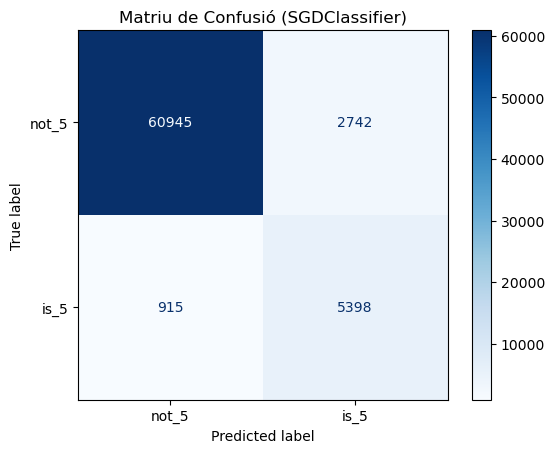

In [12]:

# 6. Visualitzem la matriu gràficament
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["not_5", "is_5"]) # O simplement sense display_labels
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriu de Confusió (SGDClassifier)")
plt.show()

#### Precision / Recall

In [13]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train_5_cv, y_train_pred))
print("Recall:", recall_score(y_train_5_cv, y_train_pred))

Precision: 0.6631449631449632
Recall: 0.8550609852684936


#### Compensació entre Precision/Recall

Amb `decision_function` obtenim les puntuacions entre un parell de classes. La **`decision_function`** és un mètode que tenen molts classificadors de scikit-learn (com `SGDClassifier`, `LogisticRegression` o `SVC`) que et retorna **la puntuació de confiança (o marge)** de cada mostra respecte a les classes, en lloc de donar-te directament la classe predita (com fa `.predict()`).

Si és negatiu prediu 0, és a dir, que no és 5 i si és positiu prediu 1, és a dir, 5.

Per tant, si coneguem quant de segur està un model d'un número, podem exigir més seguretat o menys per a la predicció. A més seguretat, augmentarà la precisió. Per tant, no fallarà tant en les respostes positives. No obstant es deixarà moltes positives per detectar. Si deixem més laxitud a l'hora de detectar els positius, tindrem menys precisió i més `recall` o memòria. 



In [14]:
mnist.frame[mnist.frame['class'] == "5"].head(5)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
35,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
47,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
65,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [15]:
y_scores = sgd_clf.decision_function(X[mnist.frame['class'] == "5"].head(5))  # Com que X no té les etiquetes, només passem les imatges de la classe 5 per obtenir els scores de decisió
y_scores

array([-372.88017823, 1850.88811131,  711.7565112 , 5704.75748092,
       7238.12977916])

In [16]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False,  True,  True,  True,  True])

In [17]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False, False, False, False, False])

In [18]:
from sklearn.model_selection import cross_val_predict

y_train_5_cm = (y == 5)
y_scores = cross_val_predict(sgd_clf_cm, X, y_train_5_cm, cv=3, method="decision_function")

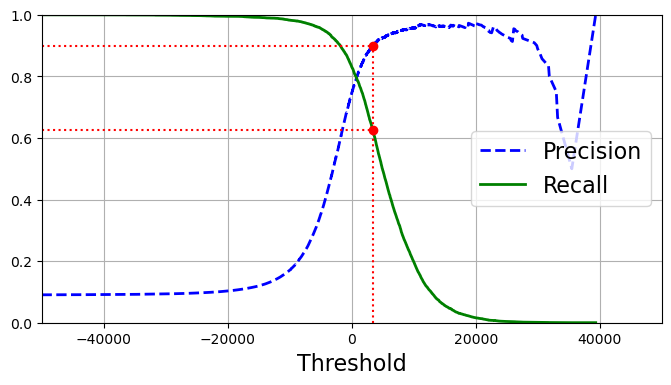

In [19]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5_cm, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2) #b- tipo de linea
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2) #g-- tipo del linea
    plt.legend(loc="center right", fontsize=16) 
    plt.xlabel("Threshold", fontsize=16)        
    plt.grid(True)                              
    plt.axis([-50000, 50000, 0, 1])             



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))                                                                  
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                                                                          
plt.show()

Si volem evitar els falsos negatius, necessitem un recall alt (idealment 1).

El preu a pagar és que acceptarem molts falsos positius (la precisió baixarà).

> Tot depèn del cas d'ús: no tenir falsos negatius és crític en medicina (per exemple, no detectar un tumor), on prefereixes espantar el pacient amb un fals positiu que deixar escapar un malalt real. En canvi, en un filtre de correu borrissol (spam), potser prefereixes no tenir falsos positius (que un correu important vagi a spam).


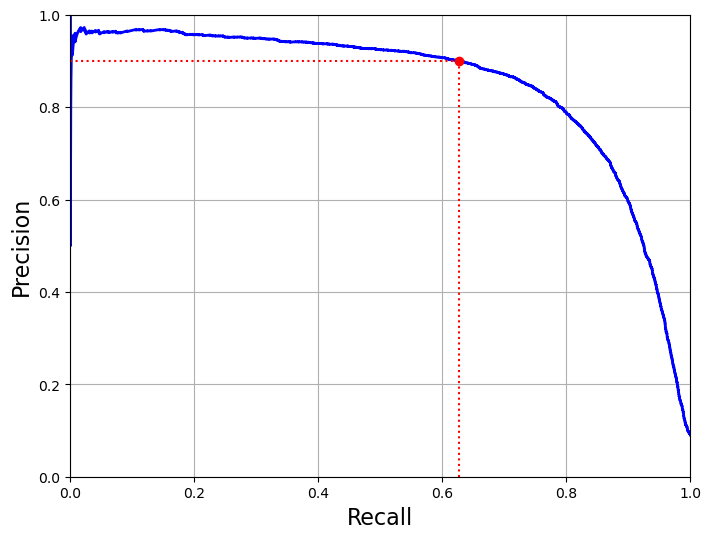

In [20]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")

plt.show()

Al fer `precision_recall_curve` obtenim uns arrays que serveixen per a fer el gràfic, però també per pendre decisions. En la gràfica anterior i la de dalt, hem buscat el lloc on la precisió és 90. S'ha fet amb `argmax`, que és una funció molt útil del `Numpy` que ens indica la posició del primer True que troba a l'array (1). Com que l'array començarà amb poca precisió, els primers elements són False. El màxim és 1 (True) i per tant troba el primer True. 

In [21]:
print(precisions)
print("Recall at 90% precision:", recall_90_precision)
print('Llindar a 90% de precisió: ',threshold_90_precision)

[0.09018571 0.090187   0.09018829 ... 0.5        1.         1.        ]
Recall at 90% precision: 0.6261682242990654
Llindar a 90% de precisió:  3349.1918425320832


Si utilitzem el criteri del 90% tindrem un 90% de precisió i menys recall:

In [22]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
precision_90 = precision_score(y_train_5_cm, y_train_pred_90)
recall_90 = recall_score(y_train_5_cm, y_train_pred_90)
print('El valor de la precisió és: ',precision_90)
print('El valor de la memòria és: ',recall_90)

El valor de la precisió és:  0.9000455373406193
El valor de la memòria és:  0.6261682242990654


#### Curva ROC

La curva ROC representa la tasa positiva verdadera (Recall) en comparació amb la tasa positiva falsa. És una representació de la sensibilitat o Recall. 

Igual que passava amb la corba de Precisió-Record, la corba ROC avalua el comportament del model a tots els llindars possibles.

* Un model perfecte tindria una corba que puja directe amunt fins a l'esquina superior esquerra (moltíssims positius veritables amb un 0% de falsos positius).
* Un model totalment aleatori seria una línia diagonal recta de punta a punta.
* Un model que estiga per sota de la línia diagonal (on l'AUC seria inferior a 0.5) és pitjor que triar a l'atzar.

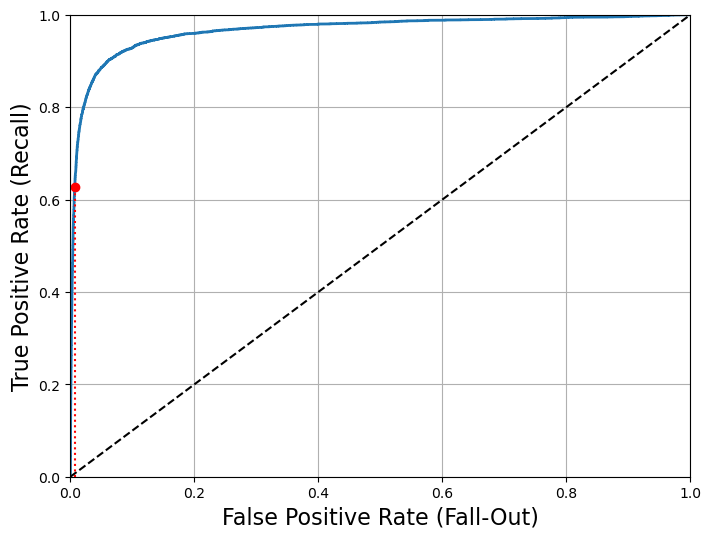

In [23]:
from sklearn.metrics import roc_curve

# roc_curve retorna tres arrays: fpr (false positive rate), tpr (true positive rate) i thresholds (llindars corresponents)
fpr, tpr, thresholds = roc_curve(y_train_5_cm, y_scores)


def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) 
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                                    
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  
plt.plot([fpr_90], [recall_90_precision], "ro")              
                                   
plt.show()

La corva indica que, a mesura que millorem el recall també augmenta la ratio de falsos positius. 

Si no necessitem la gràfica, l'àrea baix la corva ROC ens dona la mateixa informació:

In [24]:
from sklearn.metrics import roc_auc_score

score_auc = roc_auc_score(y_train_5_cm, y_scores)
print('La puntuació AUC és: ',score_auc)

La puntuació AUC és:  0.966907458229373


Ja que estem, anem a comparar la corva ROC amb un altre:

In [26]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X, y_train_5_cm, cv=3,
                                    method="predict_proba")


In [27]:
y_probas_forest  # Primer element la probabilitat de no ser un 5 i el segon element la probabilitat de ser un 5

array([[0.11, 0.89],
       [0.98, 0.02],
       [1.  , 0.  ],
       ...,
       [0.98, 0.02],
       [0.14, 0.86],
       [0.98, 0.02]], shape=(70000, 2))

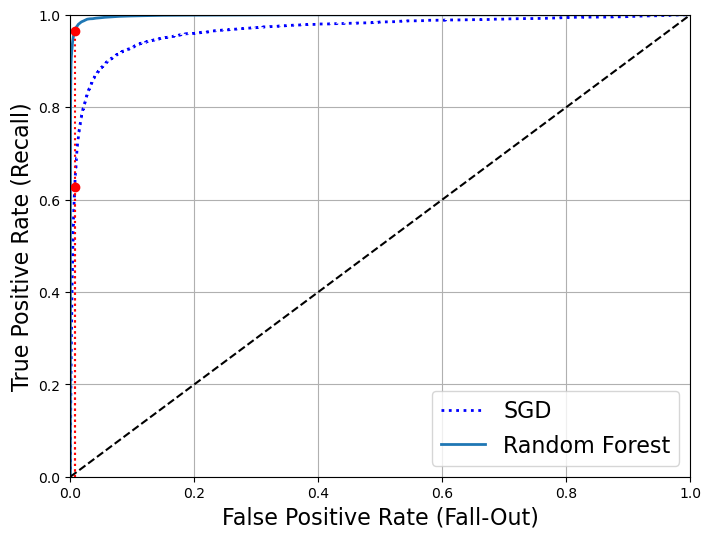

La puntuació AUC és:  0.966907458229373
La puntuació AUC del Random Forest és:  0.9984103571375105
Precisió (amb llindar 0.5): 0.9902
Record (amb llindar 0.5): 0.8772


In [28]:

y_scores_forest = y_probas_forest[:, 1] # score = probabilidad de la clase positiva
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5_cm,y_scores_forest)

recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)

plt.show()

score_auc = roc_auc_score(y_train_5_cm, y_scores)
print('La puntuació AUC és: ',score_auc)

score_auc_forest = roc_auc_score(y_train_5_cm, y_scores_forest)
print('La puntuació AUC del Random Forest és: ',score_auc_forest)

threshold = 0.5

# Fem la predicció manual comparant amb el llindar
y_pred_custom = (y_scores_forest >= threshold)

#  Calculem la precisió i el record amb aquestes prediccions
precisio = precision_score(y_train_5_cm, y_pred_custom)
record = recall_score(y_train_5_cm, y_pred_custom)

print(f"Precisió (amb llindar {threshold}): {precisio:.4f}")
print(f"Record (amb llindar {threshold}): {record:.4f}")

Queda clar que en aquest cas un `Random Forest` ha funcionat millor que `SGDClassifier`, al menys en els hiperparàmetres que hem posat.

El SGDClassifier construeix un model lineal (un únic hiperplà per separar les dades). En canvi, el Random Forest combina centenars d'arbres de decisió, la qual cosa li permet aprendre regles no lineals molt més complexes i capturar millor els patrons visuals dels dígits (com les corbes del número 5).

> Com a exercici es podria entrenar i comparar amb un model de `LogisticRegression`. 

> Tal vegada has detectat que no hem normalitzat ni escalat les dades. de 0 a 255 pot fer que el model patisca amb dades extremes. Com a exercici escala les dades i prova si funciona correctament. 

## Entrenament amb classificadors multi classe

Els `Random Forest` i derivats o els `Naive Bayes` són molt adequats per a classificacions de moltes classes. Els altres classificadors poden funcionar bé sempre que s'aplique un algorismes `One-versus-all`. 

En aquest exemple compararem l'implementació i resultats de `SVC` i `XGBoost`. Però SVC és binari, per tant, aplicarà automàticament `One VS ALL`.

`SVC` no escala bé amb moltes dades i `XGBoost` comença a ser més eficient que `SVC` a partir de moltes dades. Tot està limitat a 1000 mostres per veure els resultats en minuts, però en aquest cas `SVC` podria no ser un bon model.  


In [29]:
X, y = mnist["data"], mnist["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Valor mínim:", np.min(X_train))
print("Valor màxim:", np.max(X_train))

from sklearn.preprocessing import StandardScaler, MinMaxScaler  
scaler = MinMaxScaler() # StandScaler() # MinMaxScaler() # Escalador de min a max (0 a 1) Funciona millor al ser blanc i negre. 
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
print("Valor mínim (escalat):", np.min(X_train_scaled))
print("Valor màxim (escalat):", np.max(X_train_scaled))

Valor mínim: 0
Valor màxim: 255
Valor mínim (escalat): 0.0
Valor màxim (escalat): 1.0


In [30]:
print("Classes presents en  l'entrenament:", np.unique(y_train[:1000]))

Classes presents en  l'entrenament: [0 1 2 3 4 5 6 7 8 9]


In [31]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="scale", random_state=42)
svm_clf.fit(X_train_scaled[:1000], y_train[:1000]) # y_train, no y_train_5


,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [32]:

# 1. Escalem les dades de predicció exactament igual que les dades d'entrenament
#X_test_scaled = X.iloc[:50] / 255.0
X_test_scaled = scaler.transform(X.iloc[:50].astype(np.float64))  # Escalem les dades de test amb el mateix scaler que vam utilitzar per a l'entrenament
# 2. Fem la predicció amb les dades escalades
print("Predicció: \n", svm_clf.predict(X_test_scaled))

# 3 Imprimeix els valors reals per comparar-ho
print("Valors reals: \n", y.iloc[:50].values)

Predicció: 
 [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 3 2 4 3 2 7 3 8 6 7 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 5 3]
Valors reals: 
 [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3]


In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

xboost_clf = HistGradientBoostingClassifier(max_iter=100, random_state=42)
xboost_clf.fit(X_train_scaled[:1000], y_train[:1000]) # y_train, no y_train_5

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [34]:
print("Predicció: \n", xboost_clf.predict(X_test_scaled))

print("Valors reals: \n", y.iloc[:50].values)

Predicció: 
 [5 0 3 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 5 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 3 3]
Valors reals: 
 [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3]


### Mètriques dels dos models



In [35]:
y_train_pred = cross_val_predict(svm_clf, X_train_scaled[:1000], y_train[:1000], cv=3)
conf_mx = confusion_matrix(y_train[:1000], y_train_pred)
conf_mx

array([[109,   0,   1,   0,   0,   1,   1,   0,   0,   0],
       [  0, 103,   1,   0,   0,   0,   0,   0,   0,   0],
       [  2,   1,  86,   1,   1,   0,   2,   1,   1,   1],
       [  1,   1,   1,  95,   0,   4,   1,   1,   4,   1],
       [  0,   0,   0,   0,  67,   0,   0,   0,   1,   5],
       [  0,   0,   0,   5,   2,  92,   1,   0,   0,   1],
       [  1,   1,   1,   0,   0,   2,  99,   0,   0,   0],
       [  1,   1,   0,   1,   1,   0,   0, 104,   0,   2],
       [  1,   3,   2,   4,   1,   3,   1,   0,  71,   4],
       [  0,   0,   0,   2,   3,   0,   0,   4,   0,  92]])

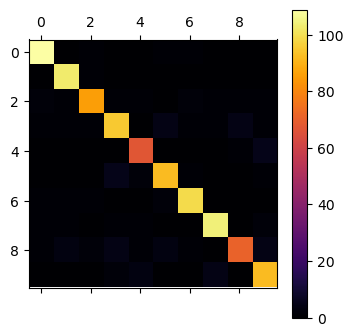

In [36]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mx, cmap="inferno")
fig.colorbar(cax)


Es veu que el 5 és més obscur. Pot ser per estar poc o mal representat o per el seu paregut a altres números com el 3 o el 2. 

Si només mirem els errors en nombres absoluts (per exemple, "el model s'ha equivocat 50 vegades amb el número 5"), et pots portar a engany:

* Potser el número 5 apareix 10.000 vegades al dataset de test (per tant, 50 errors és un percentatge mínim).
* En canvi, potser el número 5 apareix només 100 vegades (per tant, 50 errors significa que el model falla la meitat de les vegades).

Dividint cada fila de la matriu pel total d'elements de cada classe, convertim els nombres absoluts en proporcions o percentatges d'error, la qual cosa ens permet comparar classes que tenen un nombre molt diferent de mostres. 

Posant `normalize='true'` fa la divisió.

També podem omplir la diagonal de 0 per a que destaquen els errors

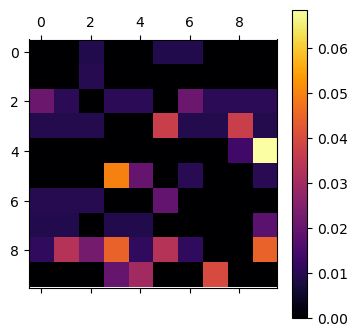

In [38]:
conf_mx_norm = confusion_matrix(y_train[:1000], y_train_pred[:1000], normalize='true')

np.fill_diagonal(conf_mx_norm, 0)

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mx_norm, cmap="inferno")
fig.colorbar(cax)

Es pot veure que la columna 8 té en general més errors que altres, això vol dir que altres números es classifiquen com 8. La fila també està més brillant, això són 8s que es confonen amb altres números. La confusió entre el 3 i el 5 i el 8 es veu ací clarament també. 

Mirem el dataset on encerta i on falla:

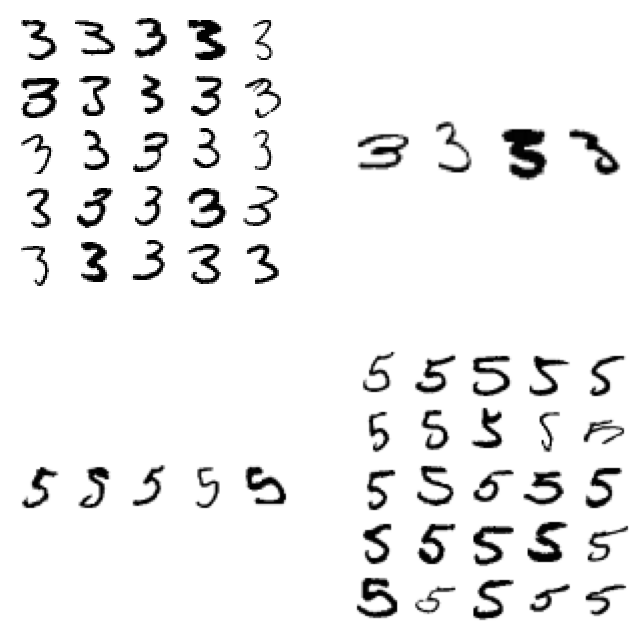

In [40]:
def plot_3_5(X_train, y_train, y_train_pred):
    cl_a, cl_b = 3, 5
    X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
    X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
    X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
    X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

    plt.figure(figsize=(8,8))
    plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
    plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
    plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
    plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)

    plt.show()

plot_3_5(X_train[:1000], y_train[:1000], y_train_pred[:1000])

Generem els mateixos gràfics per al XGBoost:

In [41]:
y_train_pred_xg = cross_val_predict(xboost_clf, X_train_scaled[:1000], y_train[:1000], cv=3)


In [42]:
conf_mx_xg = confusion_matrix(y_train[:1000], y_train_pred_xg)
conf_mx_xg

array([[107,   0,   2,   2,   0,   0,   1,   0,   0,   0],
       [  0, 100,   2,   0,   0,   0,   0,   1,   1,   0],
       [  2,   1,  81,   1,   1,   0,   4,   0,   5,   1],
       [  1,   0,   7,  90,   1,   4,   0,   1,   4,   1],
       [  1,   0,   1,   1,  59,   1,   0,   0,   1,   9],
       [  2,   0,   2,   6,   1,  85,   2,   2,   0,   1],
       [  2,   0,   0,   0,   1,   2,  97,   0,   2,   0],
       [  0,   1,   2,   0,   2,   1,   0, 101,   0,   3],
       [  0,   5,   0,   5,   0,   4,   1,   1,  65,   9],
       [  0,   0,   1,   1,   1,   1,   0,   3,   3,  91]])

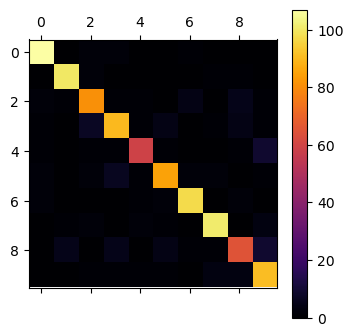

In [43]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mx_xg, cmap="inferno")
fig.colorbar(cax)

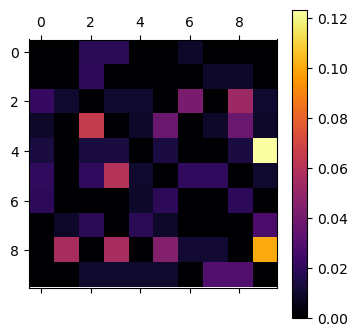

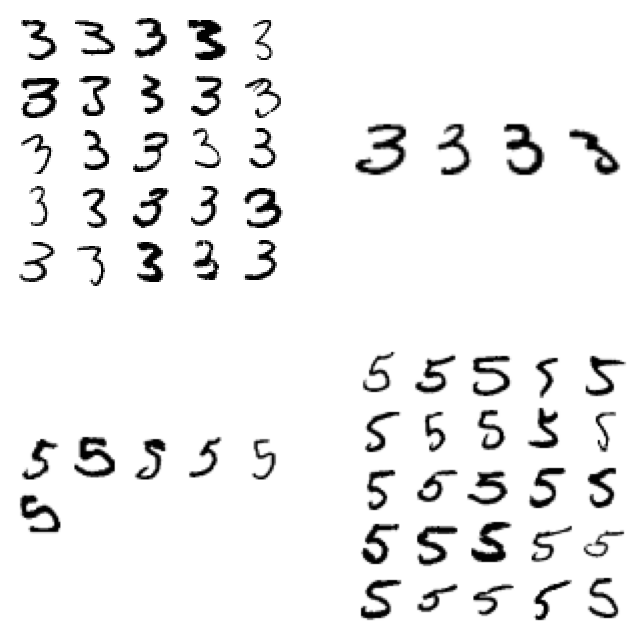

In [44]:
conf_mx_norm_xg = confusion_matrix(y_train[:1000], y_train_pred_xg, normalize='true')

np.fill_diagonal(conf_mx_norm_xg, 0)

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mx_norm_xg, cmap="inferno")
fig.colorbar(cax)

plot_3_5(X_train[:1000], y_train[:1000], y_train_pred_xg)